In [ ]:
#This notebook performs early EDA on 5-FU reports from the FDA FAERS database for all quarters in the year of 2024.

# The goal is to understand the distribution of reports across different drug combinations, identify common adverse events, and explore
#  potential patterns in the data that could inform future modeling efforts. We will focus on the most frequently reported drug combinations 
#  involving 5-FU and analyze their associated adverse events to gain insights into their safety profiles.



#Set project root variables
from pathlib import Path
import sqlite3
import pandas as pd

project_root = Path.cwd().parents[0]
db_path = project_root / "database" / "faers.db"

conn = sqlite3.connect(db_path)

In [3]:

tables = pd.read_sql_query(
"""
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name
""",
conn
)

tables

,name
0,demo
1,drug
2,faers_severity_dataset
3,fluorouracil_filtered
4,indi
5,outc
6,reac
7,rpsr
8,ther


In [4]:

like_5FU_tables = pd.read_sql_query("""

SELECT DISTINCT drugname
FROM drug
WHERE drugname LIKE '%FLUOROURACIL%'
ORDER BY drugname;
        """,
        conn)

like_5FU_tables                   


,drugname
0,5-FLUOROURACIL /00098801/
1,5fluorouracile
2,CALCIPOTRIENE\FLUOROURACIL
3,CARBOPLATIN;FLUOROURACIL
4,CYCLOPHOSPHAMIDE\EPIRUBICIN HYDROCHLORIDE\FLUO...
5,EPIRUBICIN;FLUOROURACIL
6,FLUOROURACIL
7,"FLUOROURACIL ACCORD 50 mg/ml, solution for inf..."
8,FLUOROURACIL ANABIOSIS
9,FLUOROURACIL CO [FLUOROURACIL]


In [5]:

tables = pd.read_sql_query(
"""
SELECT drugname, COUNT(*) AS reports
FROM drug
WHERE drugname LIKE '%FLUOROURACIL%'
ORDER BY drugname;
""",
conn
)

tables

,drugname,reports
0,FLUOROURACIL,13254


In [6]:
number_of_diff_FU = pd.read_sql_query("""SELECT
    drugname,
    COUNT(*) AS report_count
FROM drug
WHERE drugname LIKE '%FLUOROURACIL%'
GROUP BY drugname
ORDER BY report_count DESC;""", conn)

number_of_diff_FU

,drugname,report_count
0,FLUOROURACIL,12625
1,FLUOROURACIL\LEUCOVORIN CALCIUM\OXALIPLATIN,265
2,FLUOROURACIL\IRINOTECAN\LEUCOVORIN,124
3,FLUOROURACIL SODIUM,76
4,FLUOROURACIL\IRINOTECAN\LEUCOVORIN\OXALIPLATIN,55
5,FLUOROURACIL\LEUCOVORIN,29
6,CYCLOPHOSPHAMIDE\EPIRUBICIN HYDROCHLORIDE\FLUO...,25
7,FLUOROURACIL\LEUCOVORIN\OXALIPLATIN,12
8,TOLAK [FLUOROURACIL],4
9,FLUOROURACIL\IRINOTECAN,3


In [7]:
conn.execute("DROP TABLE IF EXISTS fluorouracil_filtered;")
conn.execute("""
CREATE TABLE fluorouracil_filtered AS
SELECT *
FROM drug
WHERE drugname IN (
    SELECT drugname
    FROM drug
    WHERE drugname LIKE '%FLUOROURACIL%'
    GROUP BY drugname
    HAVING COUNT(*) > 10
);
""")



In [8]:
FU_df_filtered = pd.read_sql_query("""
SELECT *
FROM fluorouracil_filtered
""", conn)

FU_df_filtered.shape

(13211, 21)

In [9]:
FU_df_filtered

,primaryid,caseid,drug_seq,role_cod,drugname,prod_ai,val_vbm,route,dose_vbm,cum_dose_chr,...,dechal,rechal,lot_num,exp_dt,nda_num,dose_amt,dose_unit,dose_form,dose_freq,source_quarter
0,113800407,11380040,24,SS,FLUOROURACIL,FLUOROURACIL,1,Unknown,"UNK, Cyclic",NaN,...,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1
1,113800407,11380040,25,SS,FLUOROURACIL,FLUOROURACIL,1,Unknown,UNK,NaN,...,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1
2,1177955113,11779551,38,C,FLUOROURACIL,FLUOROURACIL,1,NaN,UNK,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cream,NaN,Q1
3,125820364,12582036,8,SS,FLUOROURACIL,FLUOROURACIL,1,Unknown,cycle 8 day 1,NaN,...,U,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1
4,125820364,12582036,9,SS,FLUOROURACIL,FLUOROURACIL,1,Unknown,UNK,NaN,...,U,U,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13206,247943981,24794398,2,SS,FLUOROURACIL,FLUOROURACIL,1,Unknown,9 cycles,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q4
13207,247950291,24795029,2,SS,FLUOROURACIL,FLUOROURACIL,1,Intravenous (not otherwise specified),NaN,NaN,...,U,NaN,UNKNOWN,NaN,NaN,4654.0,MG,NaN,NaN,Q4
13208,93587883,9358788,3,SS,FLUOROURACIL,FLUOROURACIL,1,Parenteral,"UNK UNK,QCY",NaN,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/CYCLE,Q4
13209,93587883,9358788,4,SS,FLUOROURACIL,FLUOROURACIL,1,NaN,NaN,NaN,...,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Q4


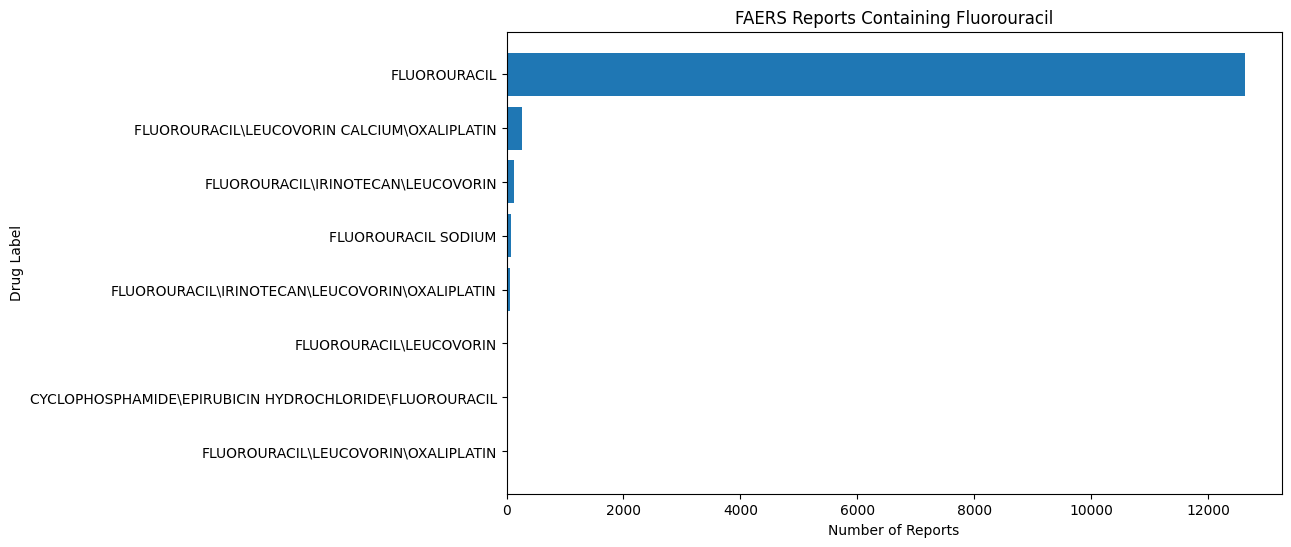

In [13]:

drug_counts = (
    FU_df_filtered
    .groupby("drugname")
    .size()
    .reset_index(name="reports")
    .sort_values("reports", ascending=False)
)

drug_counts.head(20)    


import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    drug_counts["drugname"],
    drug_counts["reports"]
)

plt.xlabel("Number of Reports")
plt.ylabel("Drug Label")
plt.title("FAERS Reports Containing Fluorouracil")
plt.gca().invert_yaxis()

plt.show()

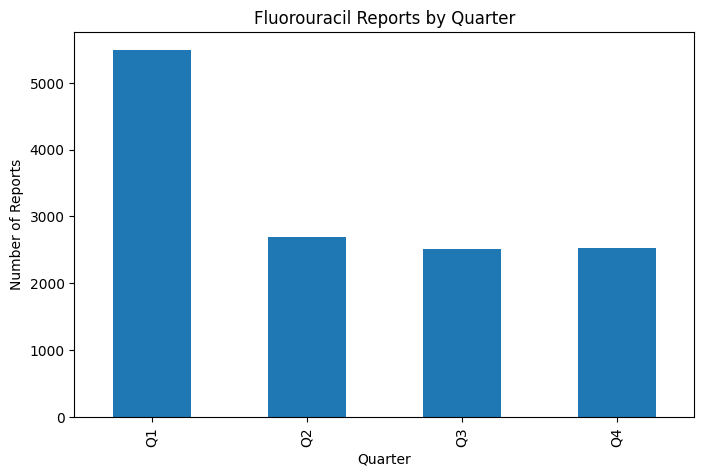

In [26]:
import matplotlib.pyplot as plt

quarter_counts = FU_df_filtered.groupby("source_quarter").size()

quarter_counts = quarter_counts.reindex(["Q1", "Q2", "Q3", "Q4"], fill_value=0)

quarter_counts.plot(kind="bar", figsize=(8,5))

plt.xlabel("Quarter")
plt.ylabel("Number of Reports")
plt.title("Fluorouracil Reports by Quarter")
plt.show()

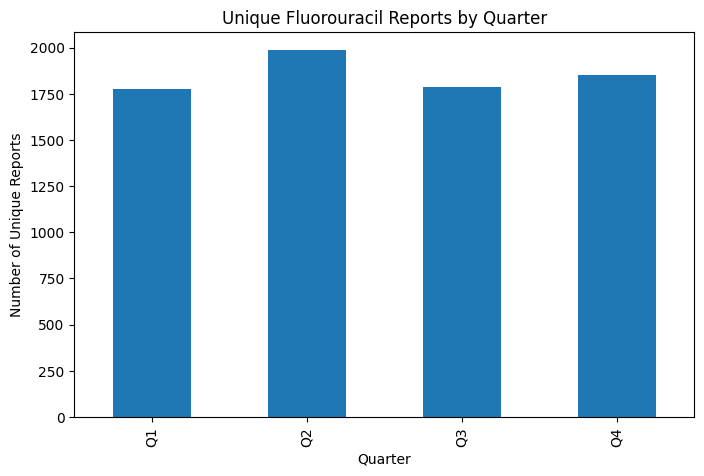

In [25]:
import matplotlib.pyplot as plt

quarter_counts = FU_df_filtered.groupby("source_quarter")["primaryid"].nunique()

quarter_counts = quarter_counts.reindex(["Q1", "Q2", "Q3", "Q4"], fill_value=0)

quarter_counts.plot(kind="bar", figsize=(8,5))

plt.xlabel("Quarter")
plt.ylabel("Number of Unique Reports")
plt.title("Unique Fluorouracil Reports by Quarter")
plt.show()

In [32]:
# Query the FAERS database to get adverse reactions (symptoms)
# associated specifically with Fluorouracil reports


reactions = pd.read_sql_query("""
SELECT
    r.pt AS symptom,
    COUNT(*) AS symptom_count
FROM reac r
JOIN (
    SELECT DISTINCT primaryid
    FROM drug
    WHERE drugname IN (
        'FLUOROURACIL',
        'FLUOROURACIL\\LEUCOVORIN CALCIUM\\OXALIPLATIN',
        'FLUOROURACIL\\IRINOTECAN\\LEUCOVORIN',
        'FLUOROURACIL SODIUM',
        'FLUOROURACIL\\IRINOTECAN\\LEUCOVORIN\\OXALIPLATIN'
    )
) f
    ON r.primaryid = f.primaryid
GROUP BY r.pt
ORDER BY symptom_count DESC;
""", conn)

reactions.head(20)

,symptom,symptom_count
0,Diarrhoea,806
1,Off label use,698
2,Neutropenia,590
3,Nausea,537
4,Disease progression,428
5,Neuropathy peripheral,410
6,Drug ineffective,405
7,Thrombocytopenia,396
8,Malignant neoplasm progression,375
9,Vomiting,371


In [34]:
reactions_for_combos = pd.read_sql_query(r"""
SELECT
    r.pt AS symptom,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'FLUOROURACIL'
        THEN r.primaryid
    END) AS fluorouracil_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'FLUOROURACIL\LEUCOVORIN CALCIUM\OXALIPLATIN'
        THEN r.primaryid
    END) AS fluorouracil_leucovorin_calcium_oxaliplatin_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'FLUOROURACIL\IRINOTECAN\LEUCOVORIN'
        THEN r.primaryid
    END) AS fluorouracil_irinotecan_leucovorin_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'FLUOROURACIL SODIUM'
        THEN r.primaryid
    END) AS fluorouracil_sodium_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'FLUOROURACIL\IRINOTECAN\LEUCOVORIN\OXALIPLATIN'
        THEN r.primaryid
    END) AS fluorouracil_irinotecan_leucovorin_oxaliplatin_count

FROM reac r
JOIN drug d
    ON r.primaryid = d.primaryid

WHERE d.drugname IN (
    'FLUOROURACIL',
    'FLUOROURACIL\LEUCOVORIN CALCIUM\OXALIPLATIN',
    'FLUOROURACIL\IRINOTECAN\LEUCOVORIN',
    'FLUOROURACIL SODIUM',
    'FLUOROURACIL\IRINOTECAN\LEUCOVORIN\OXALIPLATIN'
)

GROUP BY r.pt
ORDER BY fluorouracil_count DESC;
""", conn)

reactions_for_combos.head(20)

,symptom,fluorouracil_count,fluorouracil_leucovorin_calcium_oxaliplatin_count,fluorouracil_irinotecan_leucovorin_count,fluorouracil_sodium_count,fluorouracil_irinotecan_leucovorin_oxaliplatin_count
0,Diarrhoea,640,8,7,7,6
1,Off label use,538,21,22,12,6
2,Neutropenia,446,6,7,2,4
3,Nausea,410,9,3,6,3
4,Neuropathy peripheral,335,10,6,1,4
5,Drug ineffective,328,6,3,2,1
6,Disease progression,316,5,8,7,3
7,Vomiting,292,3,2,3,3
8,Thrombocytopenia,285,9,10,5,2
9,Fatigue,284,11,2,5,2


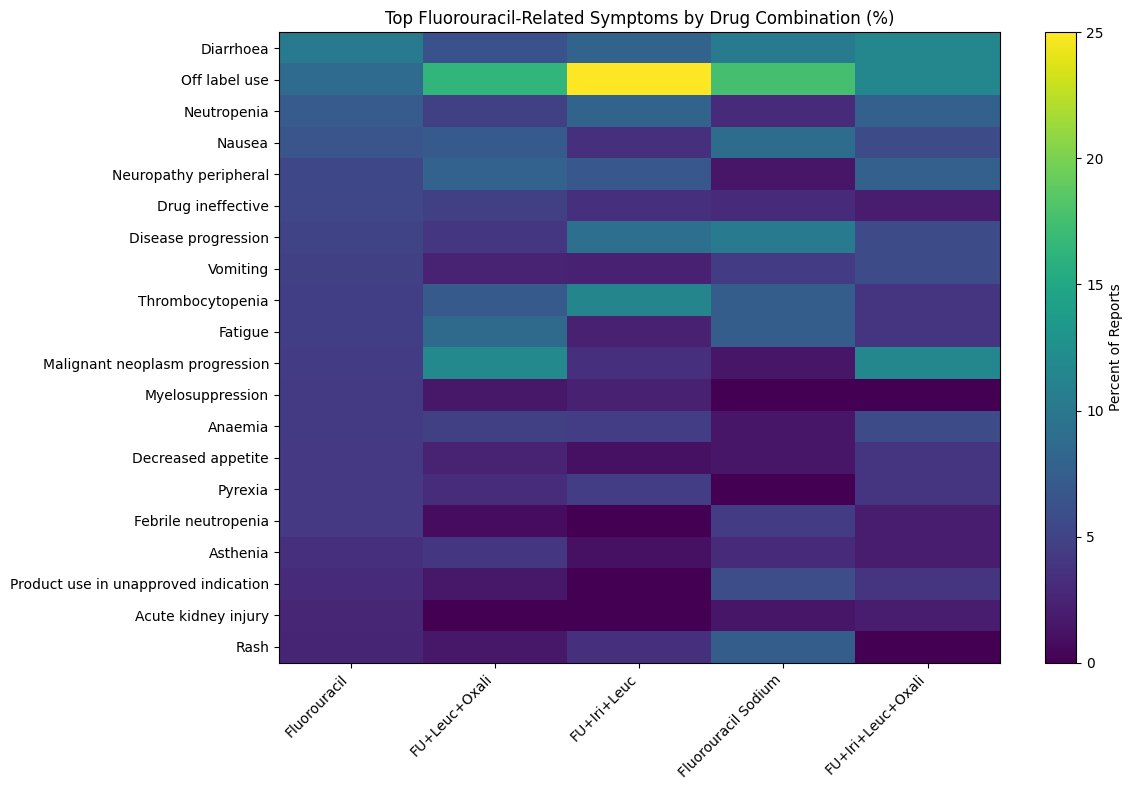

In [ ]:
# Diarrhoea: Frequent loose or watery stools
# Off label use: Drug used outside its approved indication
# Neutropenia: Low neutrophil count (increased infection risk)
# Nausea: Sensation of needing to vomit
# Neuropathy peripheral: Nerve damage causing numbness/tingling in hands or feet
# Drug ineffective: Treatment did not produce intended effect
# Disease progression: Worsening or advancement of disease
# Vomiting: Forceful expulsion of stomach contents
# Thrombocytopenia: Low platelet count (increased bleeding risk)
# Fatigue: Extreme tiredness or lack of energy
# Malignant neoplasm progression: Cancer growth or spread
# Myelosuppression: Reduced bone marrow activity (fewer blood cells produced)
# Anaemia: Low red blood cell count or hemoglobin
# Decreased appetite: Reduced desire to eat
# Pyrexia: Fever
# Febrile neutropenia: Fever with low neutrophils (serious condition)
# Asthenia: General physical weakness
# Product use in unapproved indication: Drug used for a non-approved condition
# Acute kidney injury: Sudden decline in kidney function
# Rash: Skin irritation or eruption
#


import matplotlib.pyplot as plt

# Rename columns to shorter labels for plotting
plot_df = reactions_for_combos.rename(columns={
    "fluorouracil_count": "Fluorouracil",
    "fluorouracil_leucovorin_calcium_oxaliplatin_count": "FU+Leuc+Oxali",
    "fluorouracil_irinotecan_leucovorin_count": "FU+Iri+Leuc",
    "fluorouracil_sodium_count": "Fluorouracil Sodium",
    "fluorouracil_irinotecan_leucovorin_oxaliplatin_count": "FU+Iri+Leuc+Oxali"
})

# Set symptom as index
heatmap_df = plot_df.set_index("symptom")

# Keep top 20 symptoms based on the original ordering
heatmap_df = heatmap_df.head(20)

# Normalize each column independently to percentages
heatmap_pct = heatmap_df.div(heatmap_df.sum(axis=0), axis=1) * 100

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_pct, aspect="auto")
plt.colorbar(label="Percent of Reports")

plt.xticks(
    range(len(heatmap_pct.columns)),
    heatmap_pct.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_pct.index)),
    heatmap_pct.index
)

plt.title("Top Fluorouracil-Related Symptoms by Drug Combination (%)")
plt.tight_layout()
plt.show()  